# 02b — Colab Baseline Training (YOLOv8s)

**Only training YOLOv8s, not both n and s.** The project rubric's "two competing models per
problem" requirement is satisfied at the team level -- YOLOv8 (this) vs. Faster R-CNN (teammate's
model) -- so training two YOLO sizes was redundant duplication within just this half of the
comparison. Dropping `n` roughly halves this notebook's total time. `s` was chosen (over keeping
the already-partially-trained `n` checkpoint) to match what TA Session 4 actually used as its
working example, not just listed in a comparison table.

**Resumable across Colab disconnects.** Checkpoints (`last.pt`) and training logs are written to
`RUNS_DIR` on Drive (not `/content`), specifically so they survive a session reset -- if Colab
disconnects you mid-training, re-running this notebook in a fresh session re-extracts the data
from the tar (fast, local) and then resumes training from the last completed epoch instead of
starting over.

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

!pip install ultralytics -q

Mounted at /content/drive
     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 45.5/45.5 kB 3.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 38.7 MB/s eta 0:00:00


In [ ]:
import sys
from pathlib import Path

SCRIPTS_DIR = Path("/content/drive/Shareddrives/Computer Vision Final Project/Modeling/YOLO")
sys.path.insert(0, str(SCRIPTS_DIR))

from yolo_common_colab import *

data_yaml_path, data_yaml, unified_classes, train_image_paths, val_image_paths, test_image_paths = load_dataset()
DEVICE = get_device()
print(f"Training device: {DEVICE}")

Extracting /content/drive/Shareddrives/Computer Vision Final Project/Data/tar_datasets/fv40_merged.tar (3017 MB) -> /content/dataset...
34929 entries in the tar
  2000/34929  (48 files/s, ~11.4 min left)
  4000/34929  (93 files/s, ~5.5 min left)
  6000/34929  (136 files/s, ~3.6 min left)
  8000/34929  (169 files/s, ~2.7 min left)
  10000/34929  (208 files/s, ~2.0 min left)
  12000/34929  (247 files/s, ~1.5 min left)
  14000/34929  (286 files/s, ~1.2 min left)
  16000/34929  (324 files/s, ~1.0 min left)
  18000/34929  (297 files/s, ~1.0 min left)
  20000/34929  (329 files/s, ~0.8 min left)
  22000/34929  (360 files/s, ~0.6 min left)
  24000/34929  (392 files/s, ~0.5 min left)
  26000/34929  (423 files/s, ~0.4 min left)
  28000/34929  (454 files/s, ~0.3 min left)
  30000/34929  (486 files/s, ~0.2 min left)
  32000/34929  (517 files/s, ~0.1 min left)
  34000/34929  (547 files/s, ~0.0 min left)
  34929/34929  (562 files/s, ~0.0 min left)
Extraction complete in 1.0 min.
Extracting /content/

## Train YOLOv8s

In [ ]:
BASELINE_EPOCHS = 30
LOCAL_PATIENCE = 10

SAMPLE_SIZE = None
active_data_yaml_path = build_sampled_data_yaml(data_yaml_path, data_yaml, train_image_paths, SAMPLE_SIZE)
suffix = run_name_suffix(SAMPLE_SIZE)
if SAMPLE_SIZE:
    print(f"DEBUG RUN on {SAMPLE_SIZE} sampled images -- run names suffixed '{suffix}' so they never collide with a real run.")

MODEL_SIZE = "s"
baseline_results = train_or_resume(
    model_source=f"yolov8{MODEL_SIZE}.pt",
    run_name=f"baseline_yolov8{MODEL_SIZE}{suffix}",
    data=str(active_data_yaml_path),
    epochs=BASELINE_EPOCHS,
    imgsz=IMG_SIZE,
    batch=16,
    patience=LOCAL_PATIENCE,
    device=DEVICE,
    cache="disk",
    seed=42,
)

print(f"Baseline training complete for yolov8{MODEL_SIZE}.")

Creating new Ultralytics Settings v0.0.7 file ✅ 
View Ultralytics Settings with 'yolo settings' or at '/root/.config/Ultralytics/settings.json'
Update Settings with 'yolo settings key=value', i.e. 'yolo settings runs_dir=path/to/dir'. For help see https://docs.ultralytics.com/quickstart/#ultralytics-settings.
[baseline_yolov8s] Found existing checkpoint -> resuming from /content/drive/Shareddrives/Computer Vision Final Project/Data/yolo_runs_colab_tar/baseline_yolov8s/weights/last.pt
Ultralytics 8.4.118 🚀 Python-3.12.13 torch-2.11.0+cu128 CUDA:0 (Tesla T4, 14913MiB)
engine/trainer: agnostic_nms=False, amp=True, angle=1.0, augment=False, auto_augment=randaugment, batch=16, bgr=0.0, box=7.5, cache=disk, cfg=None, channels_last=False, classes=None, close_mosaic=10, cls=0.5, cls_pw=0.0, cls_remap=True, compile=False, conf=None, copy_paste=0.0, copy_paste_mode=flip, cos_lr=False, cutmix=0.0, data=/content/dataset/data_local.yaml, degrees=0.0, deterministic=True, device=0, dfl=1.5, dgrad=0.5

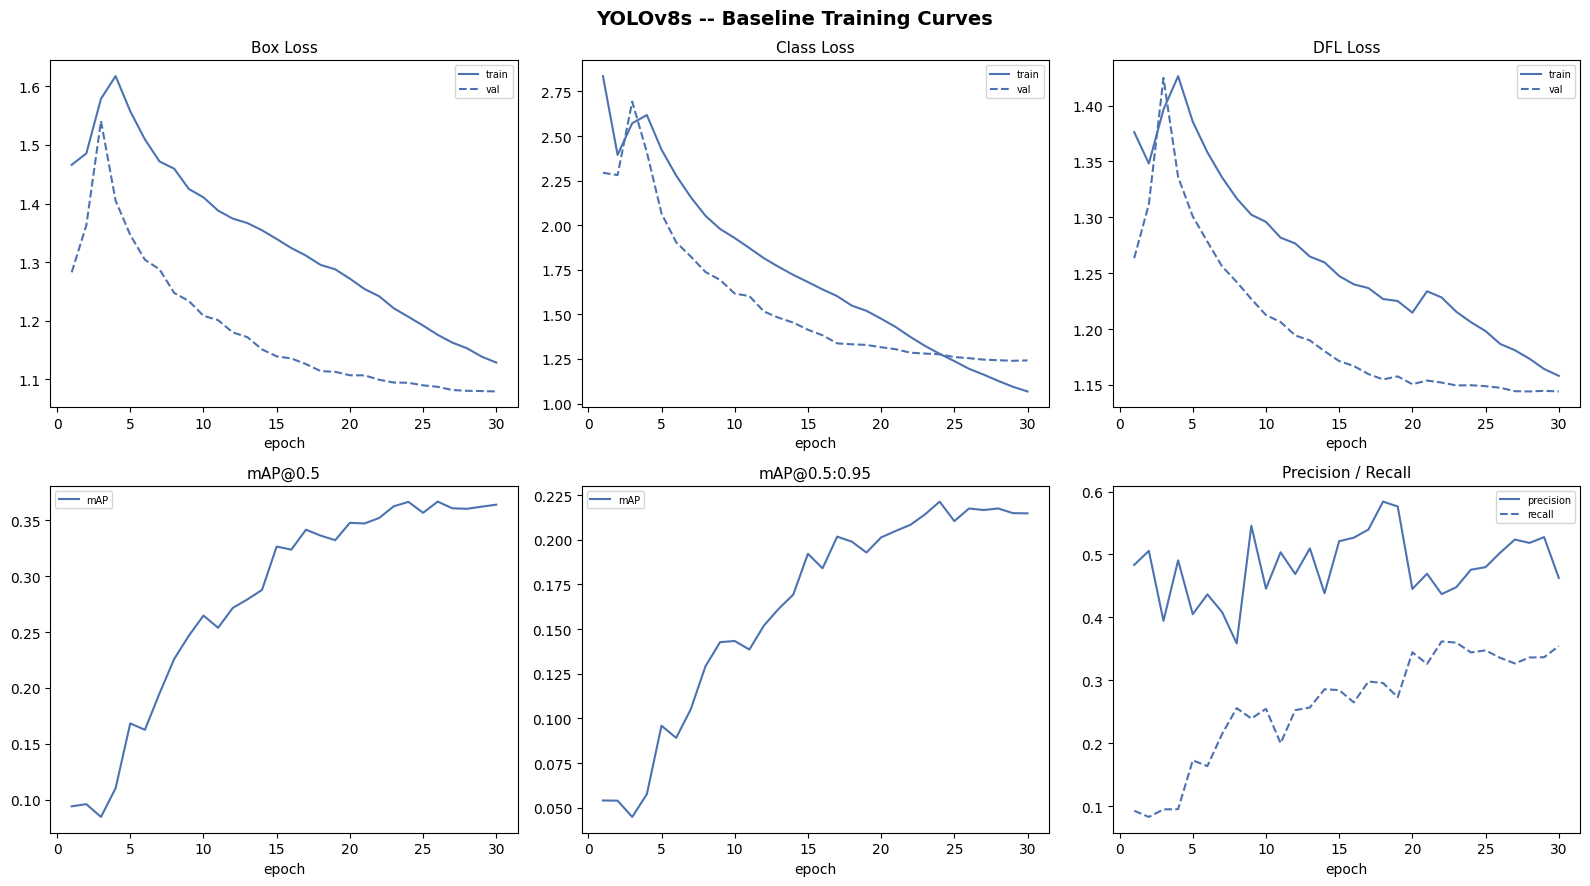

In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle(f"YOLOv8{MODEL_SIZE} -- Baseline Training Curves", fontsize=14, fontweight="bold")

metric_panels = [
    ("train/box_loss", "val/box_loss", "Box Loss"),
    ("train/cls_loss", "val/cls_loss", "Class Loss"),
    ("train/dfl_loss", "val/dfl_loss", "DFL Loss"),
    ("metrics/mAP50(B)", None, "mAP@0.5"),
    ("metrics/mAP50-95(B)", None, "mAP@0.5:0.95"),
    ("metrics/precision(B)", "metrics/recall(B)", "Precision / Recall"),
]

csv_path = RUNS_DIR / f"baseline_yolov8{MODEL_SIZE}{suffix}" / "results.csv"
df = pd.read_csv(csv_path)
df.columns = df.columns.str.strip()

for ax, (col_a, col_b, title) in zip(axes.flat, metric_panels):
    if col_a in df.columns:
        label_a = "train" if title in ("Box Loss", "Class Loss", "DFL Loss") else "mAP" if "mAP" in title else "precision"
        ax.plot(df["epoch"], df[col_a], label=label_a, color="#4C72B0")
    if col_b and col_b in df.columns:
        label_b = "val" if title in ("Box Loss", "Class Loss", "DFL Loss") else "recall"
        ax.plot(df["epoch"], df[col_b], label=label_b, color="#4C72B0", linestyle="--")
    ax.set_title(title, fontsize=11)
    ax.set_xlabel("epoch")

for ax in axes.flat:
    ax.legend(fontsize=7)

plt.tight_layout()
plt.show()